In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")



In [5]:
df = pd.read_csv("D:\pythonML-class\Sleep_health_and_lifestyle_dataset.csv")
print(df.head())
print(df.info())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [6]:
df["Sleep Disorder"].fillna("None", inplace=True)

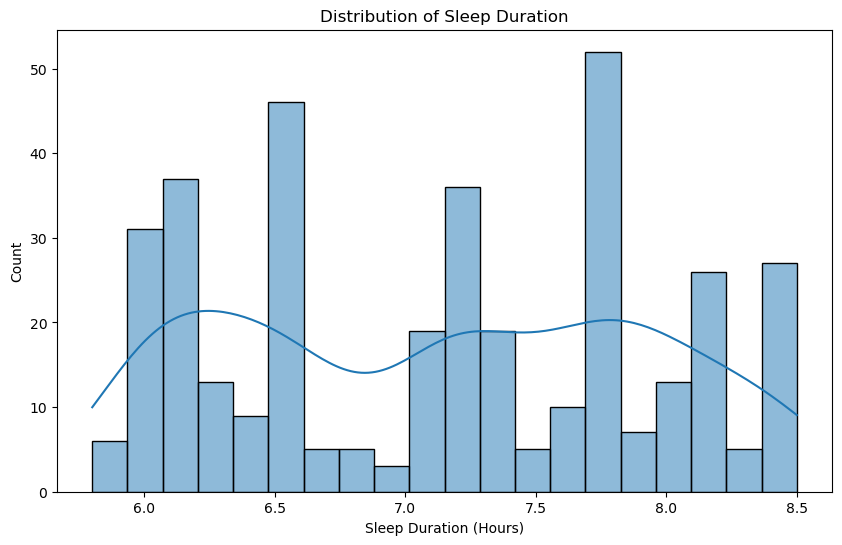

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sleep Duration'], kde=True, bins=20)
plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Count")
plt.show()

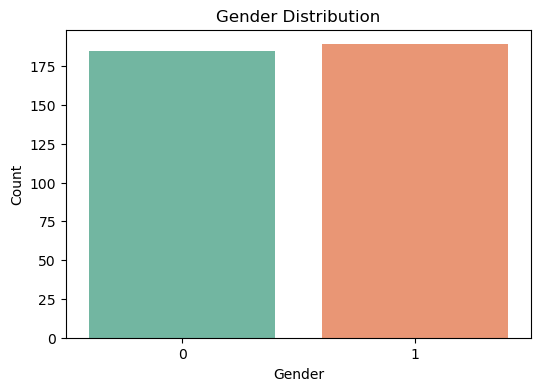

In [15]:
# gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

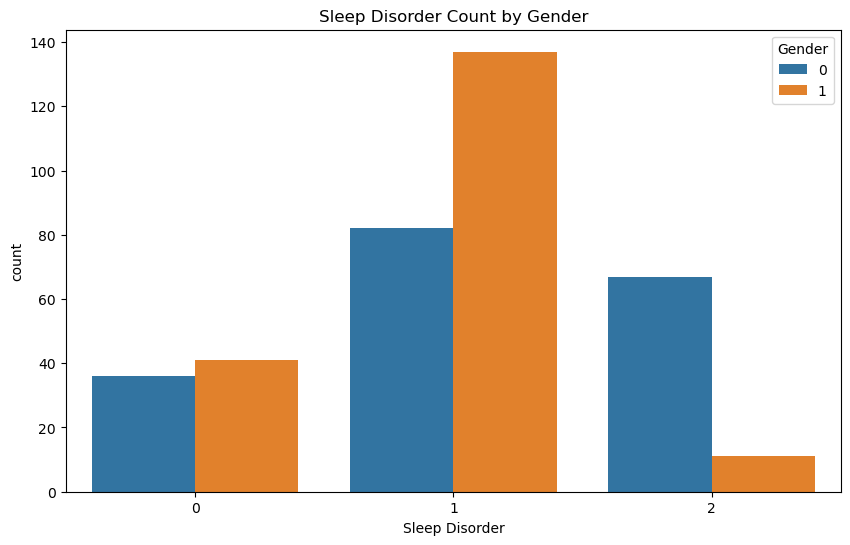

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(x='Sleep Disorder', hue='Gender', data=df)
plt.title("Sleep Disorder Count by Gender")
plt.show()


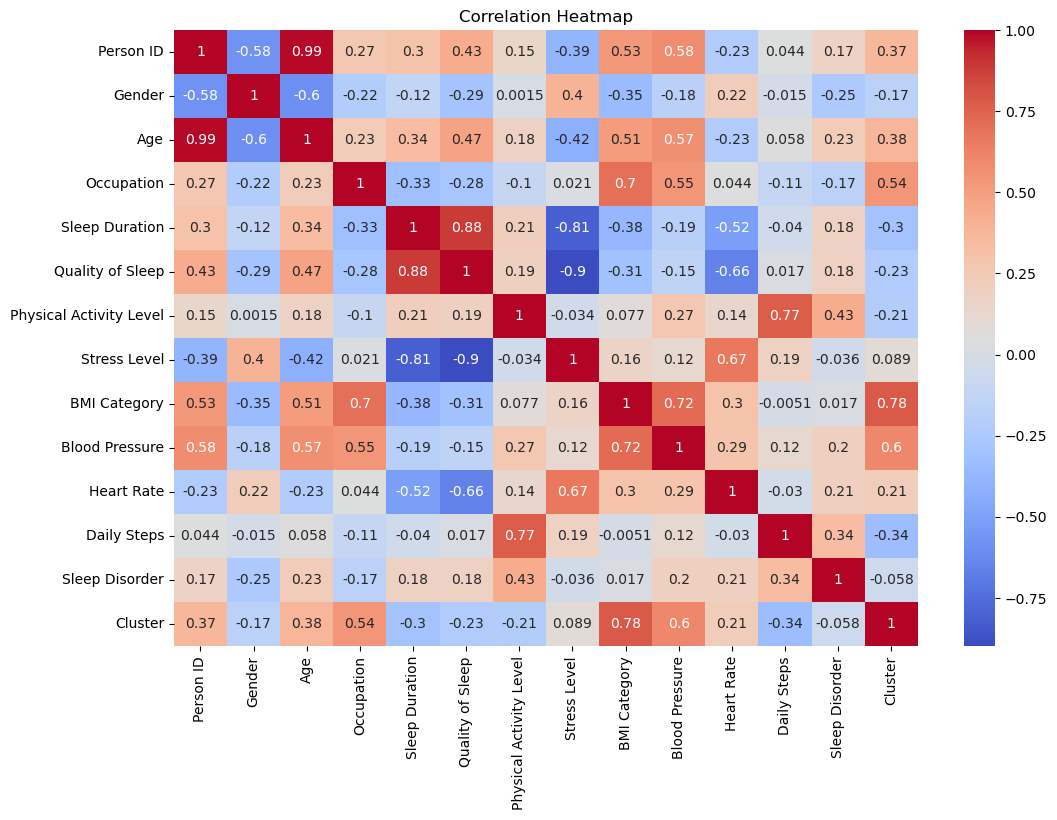

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Categorical:", categorical_cols.tolist())
p
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

Categorical: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
   Person ID  Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0          1       1   27           9             6.1                 6   
1          2       1   28           1             6.2                 6   
2          3       1   28           1             6.2                 6   
3          4       1   28           6             5.9                 4   
4          5       1   28           6             5.9                 4   

   Physical Activity Level  Stress Level  BMI Category  Blood Pressure  \
0                       42             6             3              11   
1                       60             8             0               9   
2                       60             8             0               9   
3                       30             8             2              22   
4                       30             8             2              22   

   Heart Rate 

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

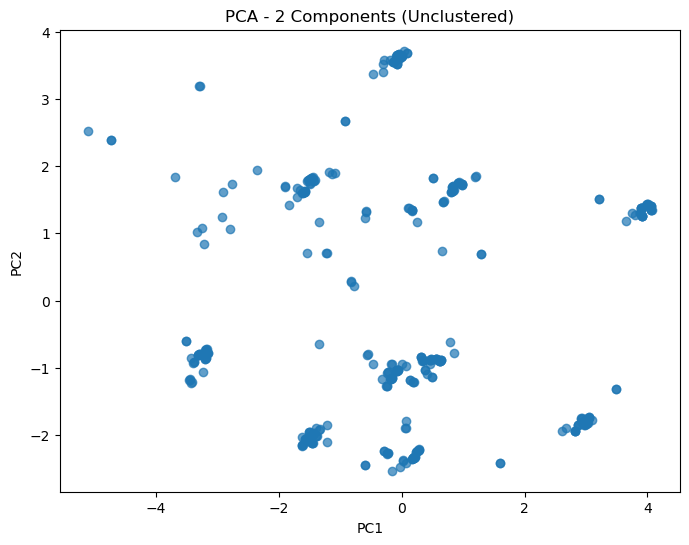

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.title("PCA - 2 Components (Unclustered)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [10]:
print("\nSilhouette Scores:")
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"k={k}: silhouette={sil}")


Silhouette Scores:
k=2: silhouette=0.2817402087183733
k=3: silhouette=0.31090424824189417
k=4: silhouette=0.36036353316538383
k=5: silhouette=0.4303585105717296
k=6: silhouette=0.474473072684275
k=7: silhouette=0.5018895547855448
k=8: silhouette=0.5522740958504514


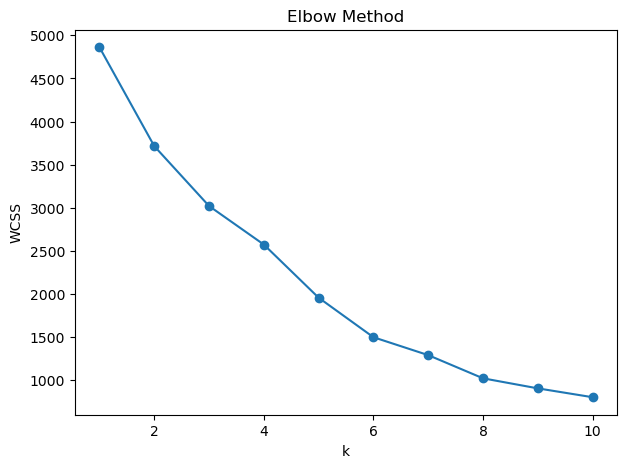

In [11]:
wcss = []
K = range(1,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
print(df.head())


   Person ID  Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0          1       1   27           9             6.1                 6   
1          2       1   28           1             6.2                 6   
2          3       1   28           1             6.2                 6   
3          4       1   28           6             5.9                 4   
4          5       1   28           6             5.9                 4   

   Physical Activity Level  Stress Level  BMI Category  Blood Pressure  \
0                       42             6             3              11   
1                       60             8             0               9   
2                       60             8             0               9   
3                       30             8             2              22   
4                       30             8             2              22   

   Heart Rate  Daily Steps  Sleep Disorder  Cluster  
0          77         4200               1        

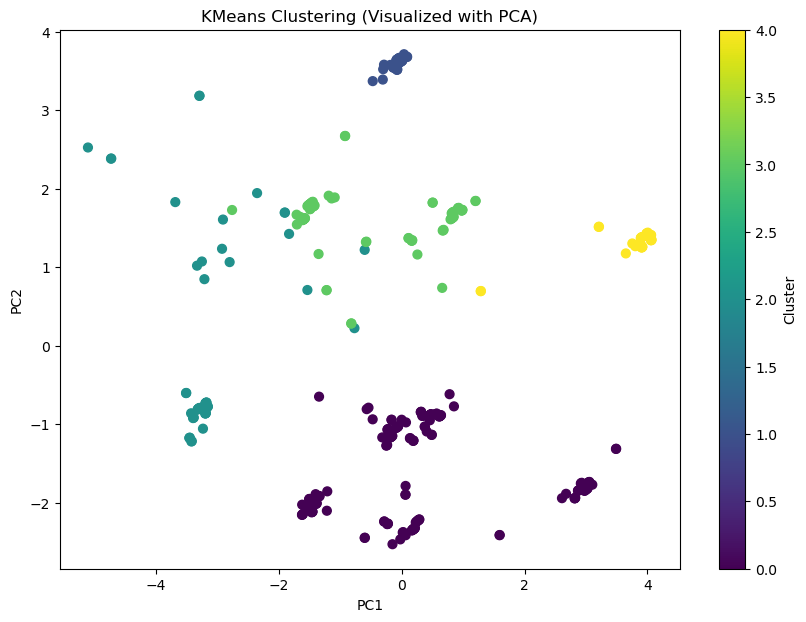

In [13]:
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", s=40)
plt.title("KMeans Clustering (Visualized with PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()